In [1]:
import os
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt


def fetch(url: str, path: str) -> np.ndarray:
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    img = cv2.imread(path)
    if img is None:
        raise RuntimeError(f"Failed to decode: {path}")
    return img


def detect_sift(gray: np.ndarray):
    sift = cv2.SIFT_create()
    return sift.detectAndCompute(gray, None)


def flann_match(des1: np.ndarray, des2: np.ndarray, ratio: float = 0.75):
    matcher = cv2.FlannBasedMatcher({"algorithm": 1, "trees": 5}, {"checks": 50})
    raw = matcher.knnMatch(des1, des2, k=2)
    return [m for m, n in raw if m.distance < ratio * n.distance]


def show(images, titles, figsize=(16, 5)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
        ax.imshow(disp)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


print("Ready.")


Ready.


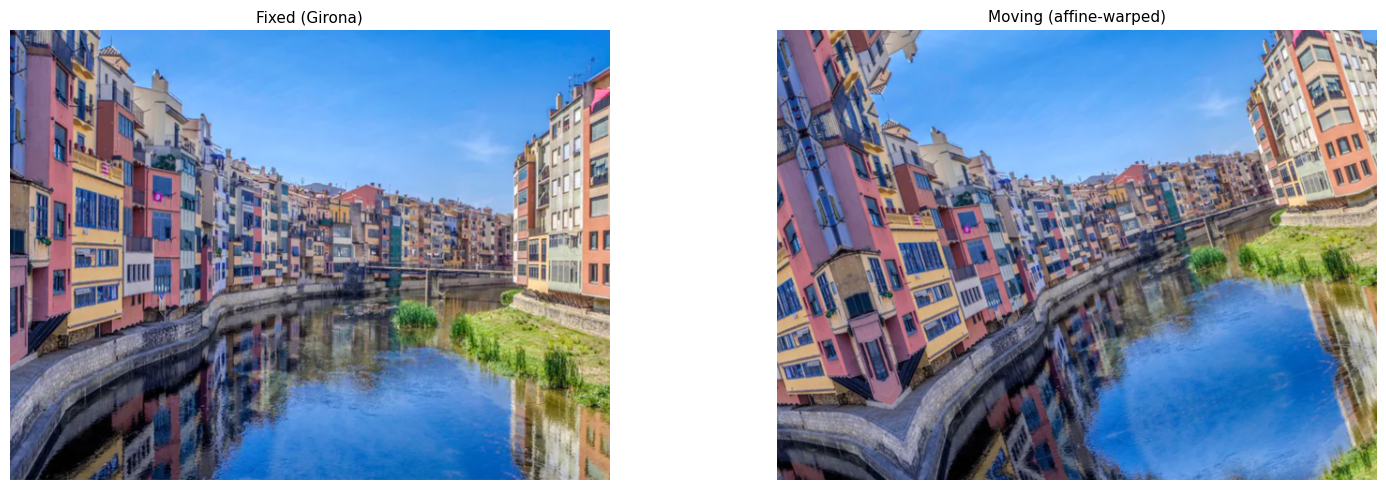

Keypoints — fixed: 3690, moving: 3905
Good matches: 2056


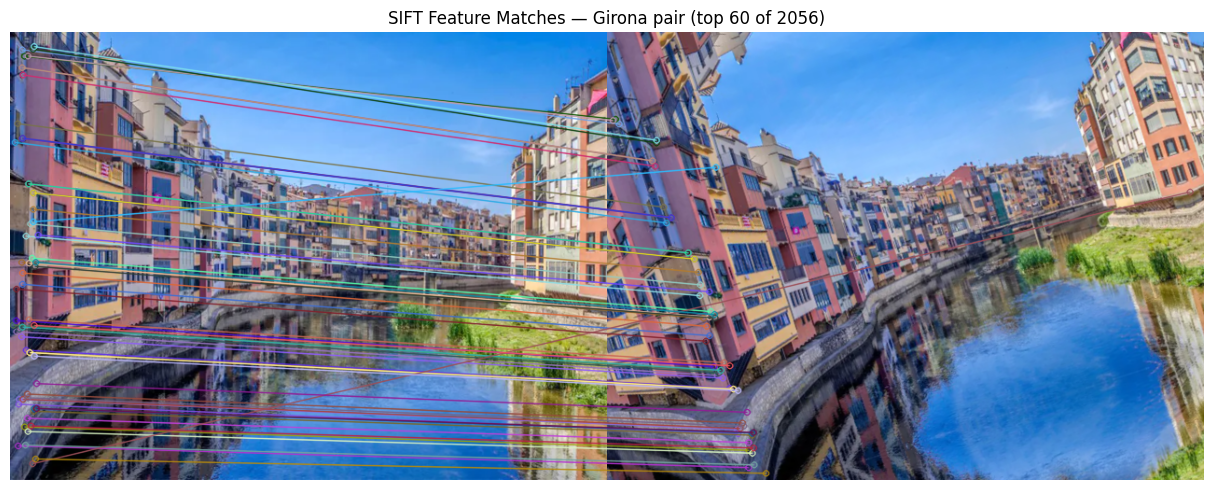


RANSAC inliers: 2018 / 2056
Estimated affine matrix (2×3):
 [[   1.1189   -0.3635    8.4308]
 [   0.3636    1.119  -133.5678]]
Ground-truth affine matrix (2×3):
 [[  0.8084   0.2627  28.2732]
 [ -0.2627   0.8084 110.0371]]


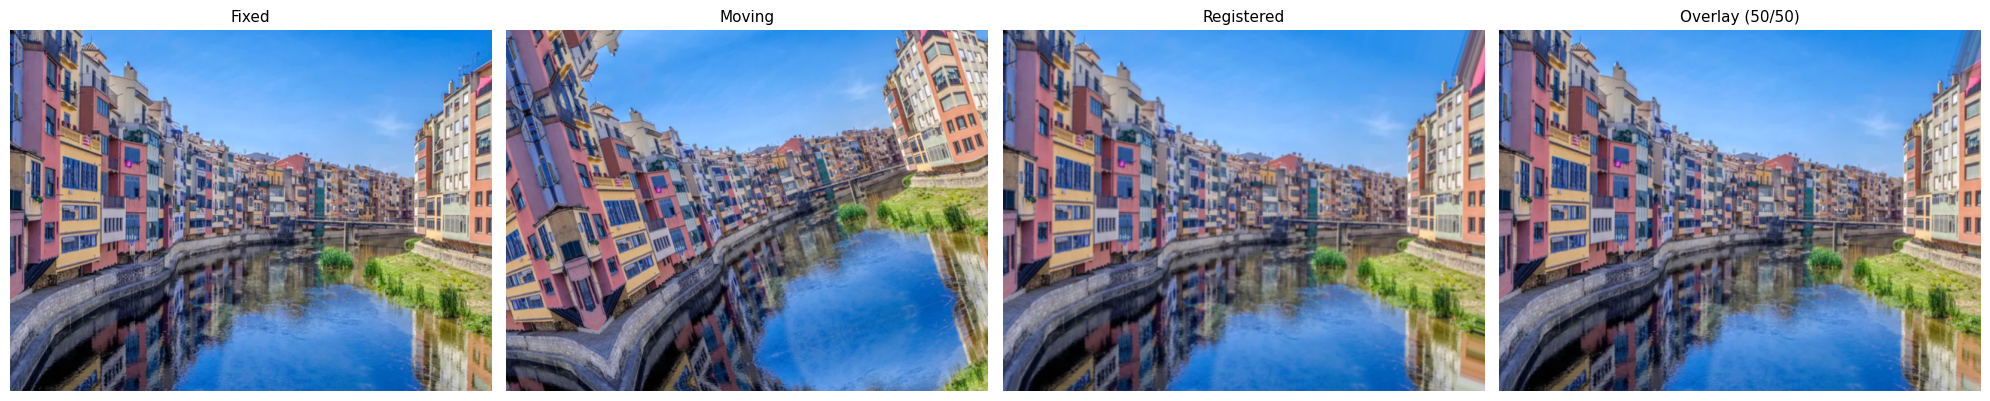

Registration complete.


In [2]:
img_fixed = fetch("https://raw.githubusercontent.com/kornia/data/main/girona.png", "reg_fixed.png")
img_fixed = cv2.resize(img_fixed, (640, 480), interpolation=cv2.INTER_AREA)

# Synthetic moving image: apply a known affine (rotation 18°, scale 0.85, translate)
cx, cy = img_fixed.shape[1] / 2, img_fixed.shape[0] / 2
M_gt   = cv2.getRotationMatrix2D((cx, cy), angle=18, scale=0.85)
M_gt[0, 2] += 30
M_gt[1, 2] -= 20
img_moving = cv2.warpAffine(img_fixed, M_gt, (img_fixed.shape[1], img_fixed.shape[0]),
                             flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

show([img_fixed, img_moving], ["Fixed (Girona)", "Moving (affine-warped)"])

g_fixed  = cv2.cvtColor(img_fixed,  cv2.COLOR_BGR2GRAY)
g_moving = cv2.cvtColor(img_moving, cv2.COLOR_BGR2GRAY)

kp1, des1 = detect_sift(g_fixed)
kp2, des2 = detect_sift(g_moving)
good = flann_match(des1, des2, ratio=0.75)

print(f"Keypoints — fixed: {len(kp1)}, moving: {len(kp2)}")
print(f"Good matches: {len(good)}")

match_img = cv2.drawMatches(
    img_fixed, kp1, img_moving, kp2, good[:60], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
plt.figure(figsize=(16, 5))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Feature Matches — Girona pair (top 60 of {len(good)})")
plt.axis("off")
plt.tight_layout()
plt.show()

if len(good) < 8:
    raise RuntimeError("Not enough matches for registration.")

src_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
dst_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)

M_est, inlier_mask = cv2.estimateAffine2D(
    src_pts, dst_pts,
    method=cv2.RANSAC, ransacReprojThreshold=3.0,
    maxIters=5000, confidence=0.99,
)
if M_est is None:
    raise RuntimeError("Affine estimation failed — not enough inliers.")
inliers = int(inlier_mask.sum()) if inlier_mask is not None else 0
print(f"\nRANSAC inliers: {inliers} / {len(good)}")
print("Estimated affine matrix (2×3):\n", np.round(M_est, 4))
print("Ground-truth affine matrix (2×3):\n", np.round(M_gt, 4))

h_f, w_f = img_fixed.shape[:2]
registered = cv2.warpAffine(img_moving, M_est, (w_f, h_f),
                             flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
overlay = cv2.addWeighted(img_fixed, 0.5, registered, 0.5, 0)

show(
    [img_fixed, img_moving, registered, overlay],
    ["Fixed", "Moving", "Registered", "Overlay (50/50)"],
    figsize=(20, 5),
)
print("Registration complete.")


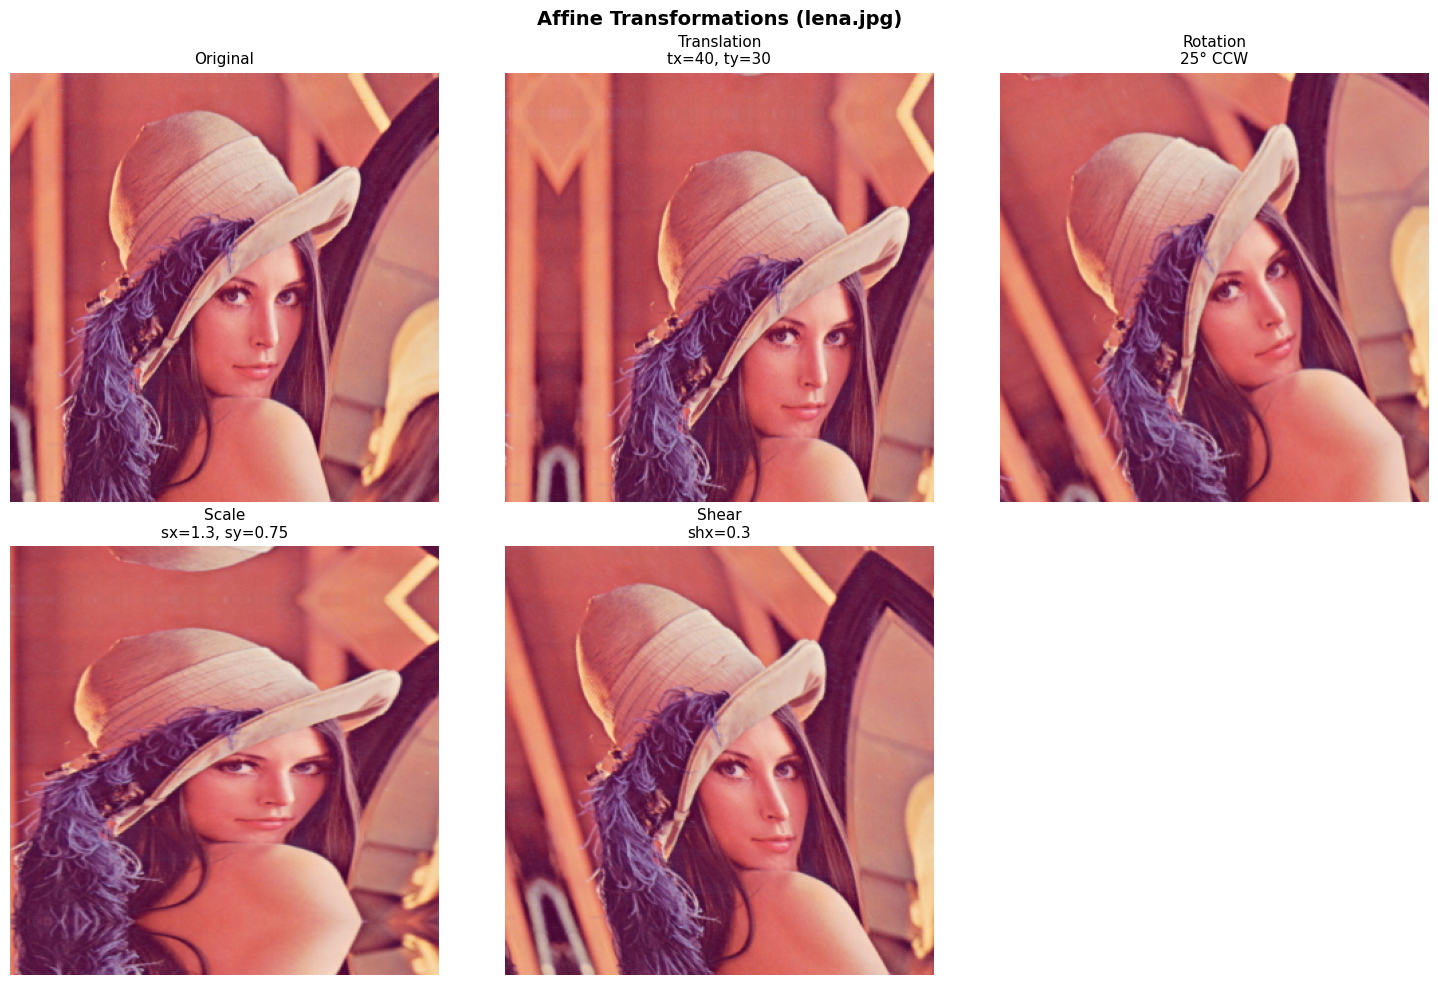

Combined matrix (2×3):
 [[ 0.8414  0.3373 10.6179]
 [-0.2329  0.8693 73.1766]]
All transforms applied.


In [3]:
BASE = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/"
aff_src = fetch(BASE + "lena.jpg", "affine_src.jpg")
aff_src = cv2.resize(aff_src, (320, 320), interpolation=cv2.INTER_AREA)

h, w  = aff_src.shape[:2]
cx, cy = w / 2.0, h / 2.0


def warp_affine(img, M):
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                          flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)


M_translate = np.float32([[1, 0, 40], [0, 1, 30]])
M_rotate    = cv2.getRotationMatrix2D((cx, cy), angle=25, scale=1.0)

sx, sy   = 1.3, 0.75
M_scale  = np.float32([[sx, 0, cx * (1 - sx)], [0, sy, cy * (1 - sy)]])

shx      = 0.3
M_shear  = np.float32([[1, shx, -cy * shx], [0, 1, 0]])

M_r3     = np.vstack([cv2.getRotationMatrix2D((cx, cy), 15, 0.9), [0, 0, 1]])
M_tx3    = np.array([[1, 0.12, 20], [0, 1, 15], [0, 0, 1]], dtype=np.float64)
M_combined = (M_tx3 @ M_r3)[:2]

transforms = [
    (M_translate, "Translation\ntx=40, ty=30"),
    (M_rotate,    "Rotation\n25° CCW"),
    (M_scale,     f"Scale\nsx={sx}, sy={sy}"),
    (M_shear,     f"Shear\nshx={shx}"),
    (M_combined,  "Combined\n(rot+scale+shear+trans)"),
]

results = [aff_src] + [warp_affine(aff_src, M) for M, _ in transforms]
titles  = ["Original"] + [t for _, t in transforms]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img, title in zip(axes.ravel(), results, titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11)
    ax.axis("off")
axes.ravel()[-1].set_visible(False)
plt.suptitle("Affine Transformations (lena.jpg)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Combined matrix (2×3):\n", np.round(M_combined, 4))
print("All transforms applied.")


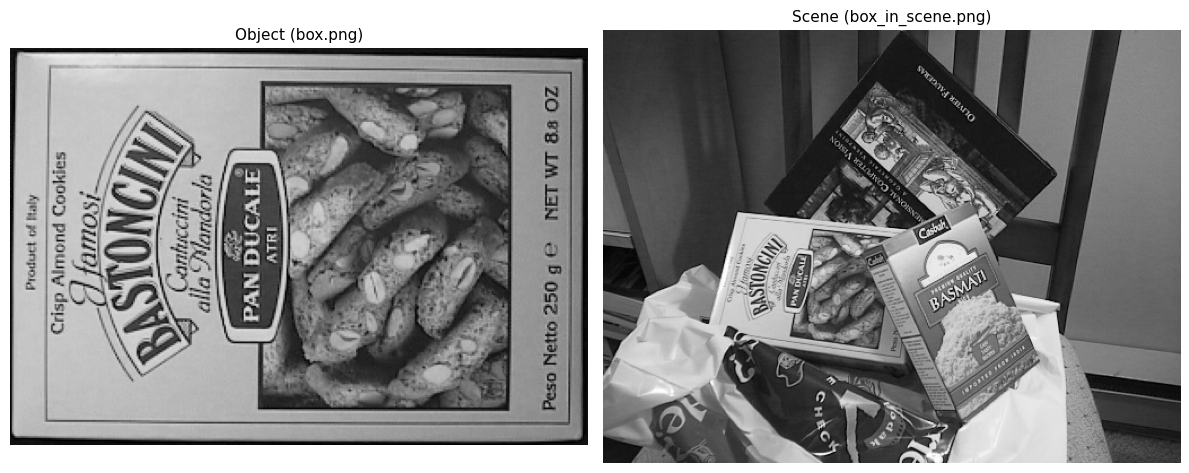

Object keypoints   : 604
Scene keypoints    : 969
Good matches       : 73
RANSAC inliers     : 71 / 73


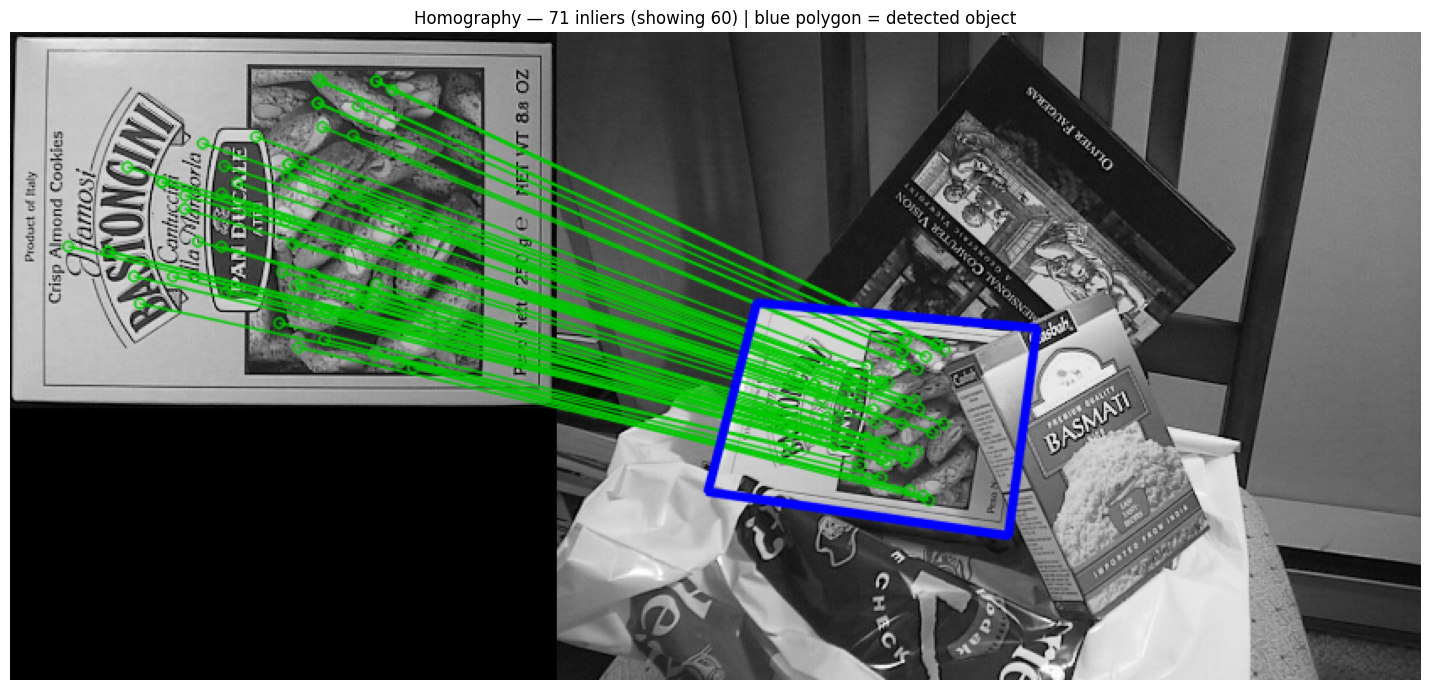

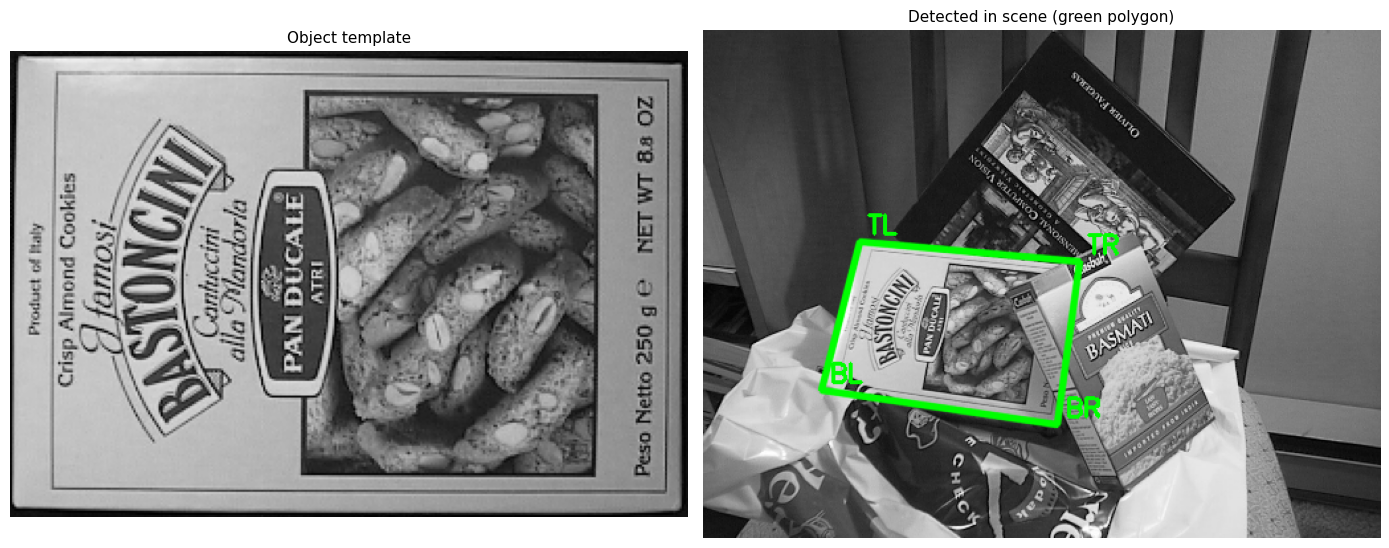


Object located.
Corners (px): [[118, 160], [284, 175], [267, 298], [89, 272]]


In [4]:
BASE = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/"
img_obj   = fetch(BASE + "box.png",          "box_obj.png")
img_scene = fetch(BASE + "box_in_scene.png", "box_scene.png")

show([img_obj, img_scene], ["Object (box.png)", "Scene (box_in_scene.png)"], figsize=(12, 5))

g_obj   = cv2.cvtColor(img_obj,   cv2.COLOR_BGR2GRAY)
g_scene = cv2.cvtColor(img_scene, cv2.COLOR_BGR2GRAY)

kp_o, des_o = detect_sift(g_obj)
kp_s, des_s = detect_sift(g_scene)
good_h = flann_match(des_o, des_s, ratio=0.7)

print(f"Object keypoints   : {len(kp_o)}")
print(f"Scene keypoints    : {len(kp_s)}")
print(f"Good matches       : {len(good_h)}")

if len(good_h) < 10:
    raise RuntimeError("Too few matches.")

obj_pts   = np.float32([kp_o[m.queryIdx].pt for m in good_h]).reshape(-1, 1, 2)
scene_pts = np.float32([kp_s[m.trainIdx].pt for m in good_h]).reshape(-1, 1, 2)

H_mat, h_mask = cv2.findHomography(obj_pts, scene_pts, cv2.RANSAC, 5.0)
h_inliers = int(h_mask.sum()) if h_mask is not None else 0
print(f"RANSAC inliers     : {h_inliers} / {len(good_h)}")

if H_mat is None:
    raise RuntimeError("Homography estimation failed.")

ho, wo        = img_obj.shape[:2]
corners_obj   = np.float32([[0,0],[wo,0],[wo,ho],[0,ho]]).reshape(-1, 1, 2)
corners_scene = cv2.perspectiveTransform(corners_obj, H_mat)

# Show 60 inlier matches for a readable visualisation
inlier_idx   = [i for i, v in enumerate(h_mask.ravel()) if v]
sampled      = [good_h[i] for i in inlier_idx[:60]]
sampled_mask = [1] * len(sampled)

match_vis = cv2.drawMatches(
    img_obj, kp_o, img_scene, kp_s, sampled, None,
    matchesMask=sampled_mask,
    matchColor=(0, 200, 0),
    singlePointColor=(180, 0, 0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
# BGR (255,0,0) -> cvtColor BGR2RGB -> (0,0,255) = blue on screen
cv2.polylines(match_vis,
              [np.int32(corners_scene + np.float32([[[wo, 0]]]))],
              isClosed=True, color=(255, 0, 0), thickness=3, lineType=cv2.LINE_AA)

plt.figure(figsize=(18, 7))
plt.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
plt.title(f"Homography — {h_inliers} inliers (showing 60) | blue polygon = detected object", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

scene_marked = img_scene.copy()
cv2.polylines(scene_marked, [np.int32(corners_scene)],
              isClosed=True, color=(0, 255, 0), thickness=3, lineType=cv2.LINE_AA)
for pt, lbl in zip(corners_scene.reshape(-1, 2), ["TL", "TR", "BR", "BL"]):
    cv2.putText(scene_marked, lbl, (int(pt[0]) + 6, int(pt[1]) - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)

show([img_obj, scene_marked],
     ["Object template", "Detected in scene (green polygon)"],
     figsize=(14, 6))

print("\nObject located.")
print(f"Corners (px): {np.int32(corners_scene).reshape(-1, 2).tolist()}")
